In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

# Load saved data
df = pd.read_csv('dissertation_data/energy_matrix.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

X = df[['Hour','Minute','ArrivalRate',
        'TotalInputTokens','TotalOutputTokens']]
y = df['Energy_Joules']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Four model comparison
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest'    : RandomForestRegressor(
                         n_estimators=100, random_state=42),
    'XGBoost'          : xgb.XGBRegressor(
                         n_estimators=200, learning_rate=0.05,
                         random_state=42, verbosity=0),
    'LightGBM'         : lgb.LGBMRegressor(
                         n_estimators=200, learning_rate=0.05,
                         random_state=42, verbose=-1)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    trained_models[name] = (model, y_pred)
    results.append({
        'Model'   : name,
        'R²'      : round(r2_score(y_test, y_pred), 4),
        'MAE (J)' : round(mean_absolute_error(y_test, y_pred), 2)
    })

results_df = pd.DataFrame(results)
print("=== MODEL COMPARISON ===")
print(results_df.to_string(index=False))

# Use XGBoost for CBIS
best_model, y_pred = trained_models['XGBoost']

# Fixed CBIS
P_IDLE = 50.0
P_ACTIVE = 350.0
CONFIDENCE_THRESHOLD = 0.15

cbis_results = []
for actual, predicted in zip(y_test.values, y_pred):
    uncertainty = abs(actual - predicted) / actual
    confidence  = 1 - uncertainty
    if confidence >= (1 - CONFIDENCE_THRESHOLD):
        if predicted < 5000:
            cbis_energy_j = P_IDLE * 60
            cbis_decision = 'SCALE_DOWN'
        else:
            cbis_energy_j = predicted
            cbis_decision = 'STAY_ACTIVE'
    else:
        cbis_energy_j = actual
        cbis_decision = 'SAFETY_BUFFER'
    cbis_results.append({
        'Actual_Energy'   : actual,
        'Predicted_Energy': predicted,
        'Confidence'      : round(confidence, 4),
        'CBIS_Decision'   : cbis_decision,
        'CBIS_Energy_J'   : cbis_energy_j
    })

cbis_df = pd.DataFrame(cbis_results)

baseline  = cbis_df['Actual_Energy'].sum()
cbis_total = cbis_df['CBIS_Energy_J'].sum()
saved     = baseline - cbis_total
saving_pct = (saved / baseline) * 100

print("\n=== CBIS RESULTS ===")
print(f"Baseline Energy : {baseline:,.0f} J")
print(f"CBIS Energy     : {cbis_total:,.0f} J")
print(f"Energy Saved    : {saved:,.0f} J")
print(f"Saving %        : {saving_pct:.2f}%")
print(f"\nSCALE_DOWN      : {(cbis_df['CBIS_Decision']=='SCALE_DOWN').sum()} mins")
print(f"STAY_ACTIVE     : {(cbis_df['CBIS_Decision']=='STAY_ACTIVE').sum()} mins")
print(f"SAFETY_BUFFER   : {(cbis_df['CBIS_Decision']=='SAFETY_BUFFER').sum()} mins")

ModuleNotFoundError: No module named 'lightgbm'

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

# Load saved data
df = pd.read_csv('dissertation_data/energy_matrix.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

X = df[['Hour','Minute','ArrivalRate',
        'TotalInputTokens','TotalOutputTokens']]
y = df['Energy_Joules']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Four model comparison
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest'    : RandomForestRegressor(
                         n_estimators=100, random_state=42),
    'XGBoost'          : xgb.XGBRegressor(
                         n_estimators=200, learning_rate=0.05,
                         random_state=42, verbosity=0),
    'LightGBM'         : lgb.LGBMRegressor(
                         n_estimators=200, learning_rate=0.05,
                         random_state=42, verbose=-1)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    trained_models[name] = (model, y_pred)
    results.append({
        'Model'   : name,
        'R²'      : round(r2_score(y_test, y_pred), 4),
        'MAE (J)' : round(mean_absolute_error(y_test, y_pred), 2)
    })

results_df = pd.DataFrame(results)
print("=== MODEL COMPARISON ===")
print(results_df.to_string(index=False))

# Use XGBoost for CBIS
best_model, y_pred = trained_models['XGBoost']

# Fixed CBIS
P_IDLE = 50.0
P_ACTIVE = 350.0
CONFIDENCE_THRESHOLD = 0.15

cbis_results = []
for actual, predicted in zip(y_test.values, y_pred):
    uncertainty = abs(actual - predicted) / actual
    confidence  = 1 - uncertainty
    if confidence >= (1 - CONFIDENCE_THRESHOLD):
        if predicted < 5000:
            cbis_energy_j = P_IDLE * 60
            cbis_decision = 'SCALE_DOWN'
        else:
            cbis_energy_j = predicted
            cbis_decision = 'STAY_ACTIVE'
    else:
        cbis_energy_j = actual
        cbis_decision = 'SAFETY_BUFFER'
    cbis_results.append({
        'Actual_Energy'   : actual,
        'Predicted_Energy': predicted,
        'Confidence'      : round(confidence, 4),
        'CBIS_Decision'   : cbis_decision,
        'CBIS_Energy_J'   : cbis_energy_j
    })

cbis_df = pd.DataFrame(cbis_results)

baseline  = cbis_df['Actual_Energy'].sum()
cbis_total = cbis_df['CBIS_Energy_J'].sum()
saved     = baseline - cbis_total
saving_pct = (saved / baseline) * 100

print("\n=== CBIS RESULTS ===")
print(f"Baseline Energy : {baseline:,.0f} J")
print(f"CBIS Energy     : {cbis_total:,.0f} J")
print(f"Energy Saved    : {saved:,.0f} J")
print(f"Saving %        : {saving_pct:.2f}%")
print(f"\nSCALE_DOWN      : {(cbis_df['CBIS_Decision']=='SCALE_DOWN').sum()} mins")
print(f"STAY_ACTIVE     : {(cbis_df['CBIS_Decision']=='STAY_ACTIVE').sum()} mins")
print(f"SAFETY_BUFFER   : {(cbis_df['CBIS_Decision']=='SAFETY_BUFFER').sum()} mins")

ModuleNotFoundError: No module named 'lightgbm'

In [2]:
import sys
!{sys.executable} -m pip install lightgbm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.5 MB/s  0:00:00


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

# Load saved data
df = pd.read_csv('dissertation_data/energy_matrix.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

X = df[['Hour','Minute','ArrivalRate',
        'TotalInputTokens','TotalOutputTokens']]
y = df['Energy_Joules']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Four model comparison
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest'    : RandomForestRegressor(
                         n_estimators=100, random_state=42),
    'XGBoost'          : xgb.XGBRegressor(
                         n_estimators=200, learning_rate=0.05,
                         random_state=42, verbosity=0),
    'LightGBM'         : lgb.LGBMRegressor(
                         n_estimators=200, learning_rate=0.05,
                         random_state=42, verbose=-1)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    trained_models[name] = (model, y_pred)
    results.append({
        'Model'   : name,
        'R²'      : round(r2_score(y_test, y_pred), 4),
        'MAE (J)' : round(mean_absolute_error(y_test, y_pred), 2)
    })

results_df = pd.DataFrame(results)
print("=== MODEL COMPARISON ===")
print(results_df.to_string(index=False))

# Use XGBoost for CBIS
best_model, y_pred = trained_models['XGBoost']

# Fixed CBIS
P_IDLE = 50.0
P_ACTIVE = 350.0
CONFIDENCE_THRESHOLD = 0.15

cbis_results = []
for actual, predicted in zip(y_test.values, y_pred):
    uncertainty = abs(actual - predicted) / actual
    confidence  = 1 - uncertainty
    if confidence >= (1 - CONFIDENCE_THRESHOLD):
        if predicted < 5000:
            cbis_energy_j = P_IDLE * 60
            cbis_decision = 'SCALE_DOWN'
        else:
            cbis_energy_j = predicted
            cbis_decision = 'STAY_ACTIVE'
    else:
        cbis_energy_j = actual
        cbis_decision = 'SAFETY_BUFFER'
    cbis_results.append({
        'Actual_Energy'   : actual,
        'Predicted_Energy': predicted,
        'Confidence'      : round(confidence, 4),
        'CBIS_Decision'   : cbis_decision,
        'CBIS_Energy_J'   : cbis_energy_j
    })

cbis_df = pd.DataFrame(cbis_results)

baseline  = cbis_df['Actual_Energy'].sum()
cbis_total = cbis_df['CBIS_Energy_J'].sum()
saved     = baseline - cbis_total
saving_pct = (saved / baseline) * 100

print("\n=== CBIS RESULTS ===")
print(f"Baseline Energy : {baseline:,.0f} J")
print(f"CBIS Energy     : {cbis_total:,.0f} J")
print(f"Energy Saved    : {saved:,.0f} J")
print(f"Saving %        : {saving_pct:.2f}%")
print(f"\nSCALE_DOWN      : {(cbis_df['CBIS_Decision']=='SCALE_DOWN').sum()} mins")
print(f"STAY_ACTIVE     : {(cbis_df['CBIS_Decision']=='STAY_ACTIVE').sum()} mins")
print(f"SAFETY_BUFFER   : {(cbis_df['CBIS_Decision']=='SAFETY_BUFFER').sum()} mins")

FileNotFoundError: [Errno 2] No such file or directory: 'dissertation_data/energy_matrix.csv'

In [4]:
import os
print("Current directory:", os.getcwd())
print("Files here:", os.listdir('.'))


Current directory: /Users/linux/Documents/ai-energy-efficiency-cloud/anaconda_projects/6898e690-a03b-47bd-ae06-0c2169876826
Files here: ['.ipynb_checkpoints', 'June 15.ipynb']


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

# Full path to your data
df = pd.read_csv('/Users/linux/dissertation_data/energy_matrix.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

X = df[['Hour','Minute','ArrivalRate',
        'TotalInputTokens','TotalOutputTokens']]
y = df['Energy_Joules']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Four model comparison
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest'    : RandomForestRegressor(
                         n_estimators=100, random_state=42),
    'XGBoost'          : xgb.XGBRegressor(
                         n_estimators=200, learning_rate=0.05,
                         random_state=42, verbosity=0),
    'LightGBM'         : lgb.LGBMRegressor(
                         n_estimators=200, learning_rate=0.05,
                         random_state=42, verbose=-1)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    trained_models[name] = (model, y_pred)
    results.append({
        'Model'   : name,
        'R²'      : round(r2_score(y_test, y_pred), 4),
        'MAE (J)' : round(mean_absolute_error(y_test, y_pred), 2)
    })

results_df = pd.DataFrame(results)
print("=== MODEL COMPARISON ===")
print(results_df.to_string(index=False))

# Use XGBoost for CBIS
best_model, y_pred = trained_models['XGBoost']

# Fixed CBIS
P_IDLE = 50.0
P_ACTIVE = 350.0
CONFIDENCE_THRESHOLD = 0.15

cbis_results = []
for actual, predicted in zip(y_test.values, y_pred):
    uncertainty = abs(actual - predicted) / actual
    confidence  = 1 - uncertainty
    if confidence >= (1 - CONFIDENCE_THRESHOLD):
        if predicted < 5000:
            cbis_energy_j = P_IDLE * 60
            cbis_decision = 'SCALE_DOWN'
        else:
            cbis_energy_j = predicted
            cbis_decision = 'STAY_ACTIVE'
    else:
        cbis_energy_j = actual
        cbis_decision = 'SAFETY_BUFFER'
    cbis_results.append({
        'Actual_Energy'   : actual,
        'Predicted_Energy': predicted,
        'Confidence'      : round(confidence, 4),
        'CBIS_Decision'   : cbis_decision,
        'CBIS_Energy_J'   : cbis_energy_j
    })

cbis_df = pd.DataFrame(cbis_results)

baseline   = cbis_df['Actual_Energy'].sum()
cbis_total = cbis_df['CBIS_Energy_J'].sum()
saved      = baseline - cbis_total
saving_pct = (saved / baseline) * 100

print("\n=== CBIS RESULTS ===")
print(f"Baseline Energy : {baseline:,.0f} J")
print(f"CBIS Energy     : {cbis_total:,.0f} J")
print(f"Energy Saved    : {saved:,.0f} J")
print(f"Saving %        : {saving_pct:.2f}%")
print(f"\nSCALE_DOWN      : {(cbis_df['CBIS_Decision']=='SCALE_DOWN').sum()} mins")
print(f"STAY_ACTIVE     : {(cbis_df['CBIS_Decision']=='STAY_ACTIVE').sum()} mins")
print(f"SAFETY_BUFFER   : {(cbis_df['CBIS_Decision']=='SAFETY_BUFFER').sum()} mins")

=== MODEL COMPARISON ===
            Model     R²  MAE (J)
Linear Regression 0.9995    30.90
    Random Forest 1.0000    13.98
          XGBoost 0.9999    20.59
         LightGBM 0.9999    19.36

=== CBIS RESULTS ===
Baseline Energy : 14,750,699 J
CBIS Energy     : 13,823,727 J
Energy Saved    : 926,972 J
Saving %        : 6.28%

SCALE_DOWN      : 914 mins
STAY_ACTIVE     : 1102 mins
SAFETY_BUFFER   : 0 mins


In [6]:
# Save CBIS results
cbis_df.to_csv('/Users/linux/dissertation_data/cbis_results.csv', 
               index=False)

# Save model comparison
results_df.to_csv('/Users/linux/dissertation_data/model_comparison.csv',
                  index=False)

print("Results saved.")


Results saved.


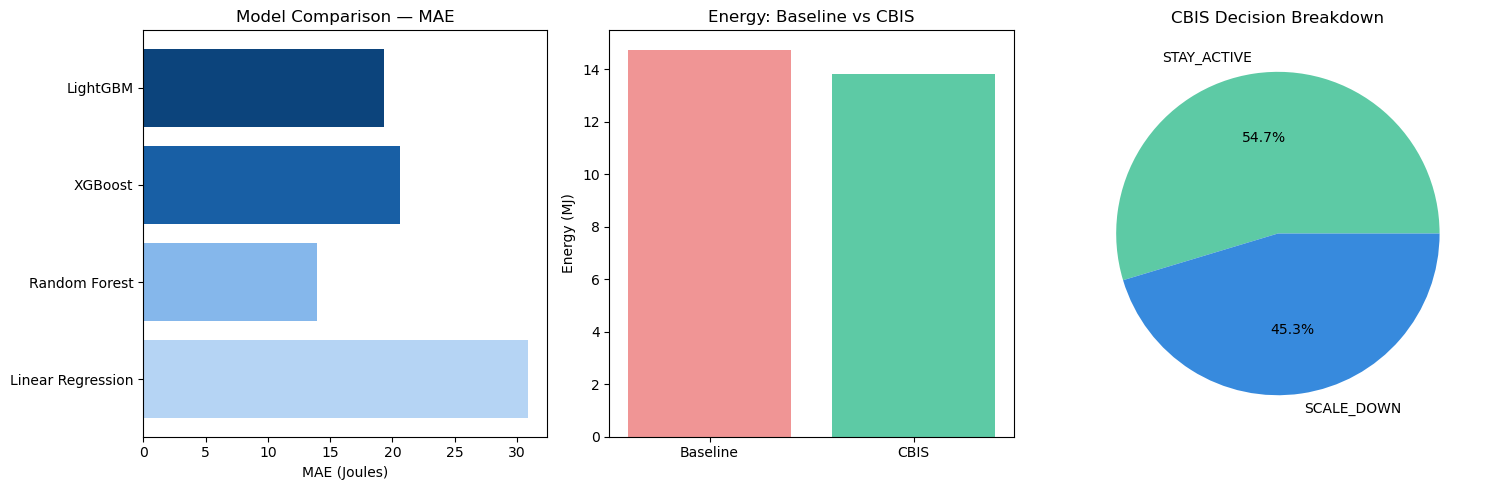

Charts saved.


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1 — Model comparison MAE
axes[0].barh(results_df['Model'], results_df['MAE (J)'], 
             color=['#B5D4F4','#85B7EB','#185FA5','#0C447C'])
axes[0].set_xlabel('MAE (Joules)')
axes[0].set_title('Model Comparison — MAE')

# Chart 2 — Energy saved vs baseline
axes[1].bar(['Baseline','CBIS'], 
            [baseline/1e6, cbis_total/1e6],
            color=['#F09595','#5DCAA5'])
axes[1].set_ylabel('Energy (MJ)')
axes[1].set_title('Energy: Baseline vs CBIS')

# Chart 3 — CBIS decision breakdown
decisions = cbis_df['CBIS_Decision'].value_counts()
axes[2].pie(decisions.values, labels=decisions.index,
            colors=['#5DCAA5','#378ADD','#EF9F27'],
            autopct='%1.1f%%')
axes[2].set_title('CBIS Decision Breakdown')

plt.tight_layout()
plt.savefig('/Users/linux/dissertation_data/final_results.png', 
            dpi=150)
plt.show()
print("Charts saved.")

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb

df = pd.read_csv('/Users/linux/dissertation_data/burstgpt_energy_matrix.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

X = df[['Hour','Minute','ArrivalRate','TotalInputTokens','TotalOutputTokens']]
y = df['Energy_Joules']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbosity=0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Model ready.")
print(f"Test set size: {len(y_test)} minutes")

Model ready.
Test set size: 17567 minutes


In [2]:
P_ACTIVE = 350.0
P_IDLE = 50.0
SCALE_DOWN_THRESHOLD = 9000
CONFIDENCE_THRESHOLD = 0.15

cbis_results = []
for actual, predicted in zip(y_test.values, y_pred):
    uncertainty = abs(actual - predicted) / actual
    confidence = 1 - uncertainty
    if confidence >= (1 - CONFIDENCE_THRESHOLD):
        if predicted < SCALE_DOWN_THRESHOLD:
            cbis_energy_j = P_IDLE * 60
            cbis_decision = 'SCALE_DOWN'
        else:
            cbis_energy_j = predicted
            cbis_decision = 'STAY_ACTIVE'
    else:
        cbis_energy_j = actual
        cbis_decision = 'SAFETY_BUFFER'
    cbis_results.append({'CBIS_Decision': cbis_decision, 'CBIS_Energy_J': cbis_energy_j, 'Actual_Energy': actual})

cbis_df = pd.DataFrame(cbis_results)
baseline = cbis_df['Actual_Energy'].sum()
cbis_total = cbis_df['CBIS_Energy_J'].sum()
saving_pct = ((baseline - cbis_total) / baseline) * 100

print(f"Baseline Energy: {baseline:,.0f} J")
print(f"CBIS Energy: {cbis_total:,.0f} J")
print(f"Saving: {saving_pct:.2f}%")

Baseline Energy: 172,508,795 J
CBIS Energy: 158,611,404 J
Saving: 8.06%
